This notebook is a localization problem. Where I simulate the performance of a single contrast localizer of different thresholds compared to  multitask localizers

In [28]:
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import matplotlib.cm as cm
import os


# first check for multitask how good the different eigen criteria are at parcellating region of interest vs everything else

In [29]:
save_dir = os.path.abspath(os.path.join(os.getcwd(),'..','eval_tsvs'))
saved_file = os.path.join(save_dir, 'sim_localization_multi.tsv')
D_multi = pd.read_csv(saved_file, sep='\t')

In [30]:
# defube metrics to plot
metrics = ['random','variance','inverse_trace_mc']
D_multi = D_multi[D_multi['metric'].isin(metrics)]

In [31]:
custom_palette = {
    'random': 'black',
    'variance': '#0072B2',
    'variance_mc': '#009E73',
    'log_det_mc': '#E69F00',
    'inverse_trace_mc': '#D55E00'
}

custom_dashes = {
    'random': (1, 1),            # dotted
    'variance': (4, 2),              # dashed
    'variance_mc': (4, 2),           # dashed
    'log_det_mc': '',        # solid
    'inverse_trace_mc': '',  # solid
}

C:\Users\barafat\AppData\Local\Temp\ipykernel_16704\3305361341.py:2: UserWarning: 
The markers list has fewer values (1) than needed (3) and will cycle, which may produce an uninterpretable plot.
  sns.lineplot(


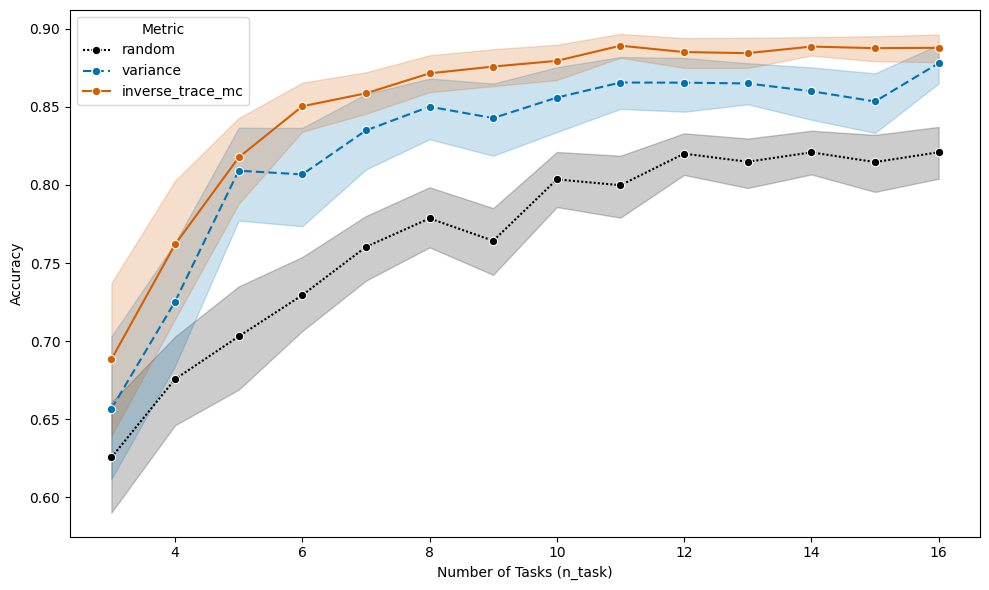

In [32]:
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=D_multi,
    x="n_task",
    y="accuracy",
    hue="metric",
    style="metric",
    palette=custom_palette,
    dashes=custom_dashes
    , markers='o'
)

plt.xlabel("Number of Tasks (n_task)")
plt.ylabel("Accuracy")
plt.legend(title="Metric")
plt.tight_layout()
plt.show()

# now compare to the single contrast localizer (use the best metric, inverse_trace_mc here)

In [33]:
metric_of_interest = 'inverse_trace_mc'
D_multi_filtered = D_multi[D_multi['metric'] == metric_of_interest]
summary_multi = D_multi_filtered.groupby('n_task')['accuracy'].agg(['mean', 'sem']).reset_index()
summary_multi.columns = ['n_task', 'mean_accuracy', 'sem_accuracy']

# load single contrast results

In [34]:
save_dir = os.path.abspath(os.path.join(os.getcwd(),'..','eval_tsvs'))
saved_file = os.path.join(save_dir, 'sim_localization_single.tsv')
D_single = pd.read_csv(saved_file, sep='\t')

# plot and compare

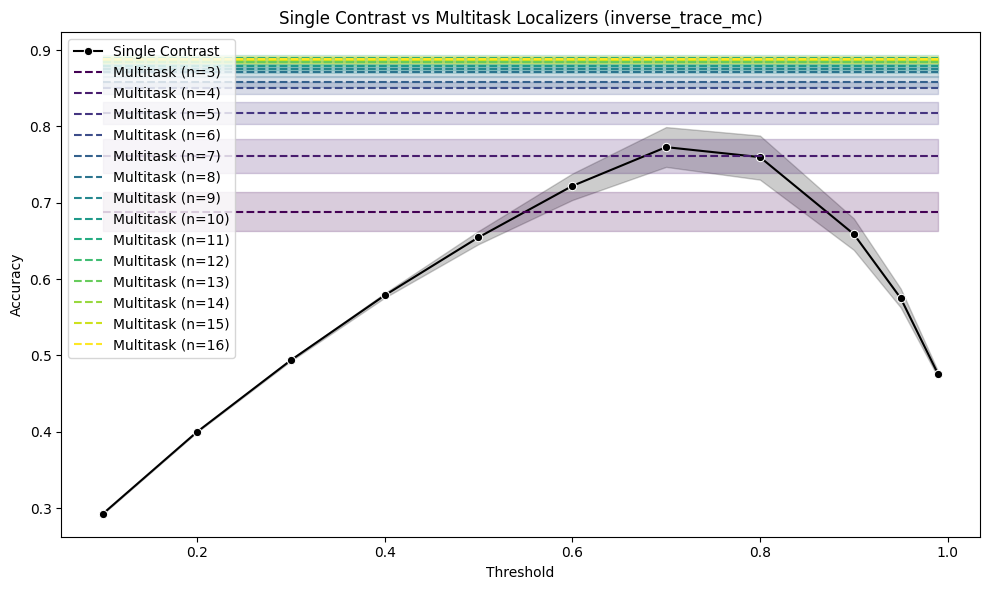

In [35]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=D_single,x="threshold", y="accuracy",label='Single Contrast',color='black',marker='o')



# add the multitask lines
colors = cm.viridis(np.linspace(0, 1, len(summary_multi)))
xmin = min(D_single['threshold'])
xmax = max(D_single['threshold'])

for i, row in summary_multi.iterrows():
    mean = row['mean_accuracy']
    sem = row['sem_accuracy']
    n_task = row['n_task']

    plt.hlines(
        y=mean,
        xmin=xmin,
        xmax=xmax,
        colors=[colors[i]],
        linestyles='dashed',
        label=f'Multitask (n={int(n_task)})'
    )

    plt.fill_between(
        [xmin, xmax],
        [mean - sem],
        [mean + sem],
        color=colors[i],
        alpha=0.2
    )

plt.xlabel('Threshold')
plt.ylabel('Accuracy')
plt.title(f'Single Contrast vs Multitask Localizers ({metric_of_interest})')
plt.legend(loc='best')
plt.tight_layout()
plt.show()
